## 1. Setup & Load Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/Dataset Nofita Skripsi/data_labeling.xlsx')
print("Data loaded:", len(df))
print("Kolom:", df.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded: 2321
Kolom: ['waktu', 'text_asli', 'terjemahan', 'negara', 'akun', 'clean', 'normal', 'tokens', 'stem', 'final_text', 'skor', 'label', 'punya_emoji', 'label_sebelum_sarkas']


In [ ]:
import pandas as pd

# Load ulang kamus normalisasi
url = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
kamus = pd.read_csv(url)
print("Kamus normalisasi ke-load:", len(kamus), "kata")

Kamus normalisasi ke-load: 15006 kata


In [ ]:
# Load ulang kamus InSet Lexicon
url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"
lex_pos = pd.read_csv(url_pos, sep='\t')
lex_neg = pd.read_csv(url_neg, sep='\t')
print("InSet ke-load: positif", len(lex_pos), "| negatif", len(lex_neg))

InSet ke-load: positif 3609 | negatif 6609


In [ ]:
# ===== SIMPAN KAMUS KE DRIVE =====
kamus.to_csv('/content/drive/MyDrive/Dataset Nofita Skripsi/kamus_normalisasi.csv', index=False)
lex_pos.to_csv('/content/drive/MyDrive/Dataset Nofita Skripsi/inset_positif.csv', index=False, sep='\t')
lex_neg.to_csv('/content/drive/MyDrive/Dataset Nofita Skripsi/inset_negatif.csv', index=False, sep='\t')
print("✅ Kamus tersimpan ke Drive!")
print("- kamus_normalisasi.csv")
print("- inset_positif.csv")
print("- inset_negatif.csv")

✅ Kamus tersimpan ke Drive!
- kamus_normalisasi.csv
- inset_positif.csv
- inset_negatif.csv


## 2. Data Selection

In [ ]:
# ===== SIMPAN PROGRESS KE DRIVE =====
df.to_excel('/content/drive/MyDrive/Dataset Nofita Skripsi/data_cleaning.xlsx', index=False)
print("✅ Progress tersimpan di Drive!")
print("File: data_cleaning.xlsx")
print("Jumlah data:", len(df))

✅ Progress tersimpan di Drive!
File: data_cleaning.xlsx
Jumlah data: 2375


In [ ]:
import os
path = '/content/drive/MyDrive/Dataset Nofita Skripsi/data_cleaning.xlsx'
if os.path.exists(path):
    print("✅ File SUDAH ada di Drive, progress aman!")
else:
    print("❌ File BELUM ada. Perlu jalanin kode simpan dulu.")

✅ File SUDAH ada di Drive, progress aman!


In [ ]:
# ===== CEK KELENGKAPAN DATASET =====
print("Total baris data:", len(df))
print("\nKolom yang ada:", df.columns.tolist())

print("\nJumlah data per negara:")
print(df['negara'].value_counts())

print("\nCek data kosong di tiap kolom:")
print(df.isna().sum())

print("\nContoh 3 data teratas & 3 terbawah:")
print(df[['negara','akun','terjemahan','clean']].head(3))
print("...")
print(df[['negara','akun','terjemahan','clean']].tail(3))

Total baris data: 2375

Kolom yang ada: ['waktu', 'text_asli', 'terjemahan', 'negara', 'akun', 'clean']

Jumlah data per negara:
negara
Belanda      1418
Indonesia     957
Name: count, dtype: int64

Cek data kosong di tiap kolom:
waktu         0
text_asli     1
terjemahan    0
negara        0
akun          0
clean         0
dtype: int64

Contoh 3 data teratas & 3 terbawah:
    negara           akun  \
0  Belanda  defanoholwijn   
1  Belanda  defanoholwijn   
2  Belanda  defanoholwijn   

                                                  terjemahan  \
0  Sebentar lagi pencuri akan membawa simpanan botol Anda...   
1        Sekarang saya akan mengunjungi tempat sampah saja 🥰   
2                       Scan mandiri solusinya, dapat uang 😆   

                                                    clean  
0  sebentar lagi pencuri akan membawa simpanan botol anda  
1       sekarang saya akan mengunjungi tempat sampah saja  
2                       scan mandiri solusinya dapat uang  
...
      

In [ ]:
import pandas as pd

# Load data yang udah difilter waktu + ditranslate
df = pd.read_excel('/content/drive/MyDrive/Dataset Nofita Skripsi/data_terjemahan.xlsx')
print("Jumlah data:", len(df))
print("Kolom:", df.columns.tolist())
df.head()

Jumlah data: 2630
Kolom: ['waktu', 'text_asli', 'terjemahan', 'negara', 'akun']


,waktu,text_asli,terjemahan,negara,akun
0,2025-01-04T17:16:02.000Z,Straks nemen inbrekers gewoon je statiegeld flessen mee..,Sebentar lagi pencuri akan membawa simpanan botol Anda...,Belanda,defanoholwijn
1,2025-01-04T15:13:03.000Z,Kga nu ook gewoon prullenbakken langs 🥰,Sekarang saya akan mengunjungi tempat sampah saja 🥰,Belanda,defanoholwijn
2,2025-01-04T15:15:45.000Z,"Zelfscan is de oplossing, krijg je er geld bij 😆","Scan mandiri solusinya, dapat uang 😆",Belanda,defanoholwijn
3,2025-01-04T18:43:52.000Z,Dalijk moeten we ook betalen om te ademen,Sebentar lagi kita juga harus membayar untuk bernafas,Belanda,defanoholwijn
4,2025-01-04T16:04:33.000Z,Zelfscan gaan dus,Jadi lakukan pemindaian mandiri,Belanda,defanoholwijn


In [ ]:
# Cek contoh data Indonesia
print("=== Contoh data INDONESIA ===")
print(df[df['negara']=='Indonesia'][['text_asli','terjemahan']].head(3))

print("\n=== Contoh data BELANDA ===")
print(df[df['negara']=='Belanda'][['text_asli','terjemahan']].head(3))

# cek ada nilai kosong di kolom terjemahan?
print("\nJumlah 'terjemahan' yang kosong:", df['terjemahan'].isna().sum())

=== Contoh data INDONESIA ===
                                         text_asli  \
1547                                   up!! boost!   
1548                              bau gak sih bg😭😭   
1549  [Sticker] "tag pemerintah"\npemerintah nya 🗿   

                                        terjemahan  
1547                                   up!! boost!  
1548                              bau gak sih bg😭😭  
1549  [Sticker] "tag pemerintah"\npemerintah nya 🗿  

=== Contoh data BELANDA ===
                                                   text_asli  \
0  Straks nemen inbrekers gewoon je statiegeld flessen mee..   
1                    Kga nu ook gewoon prullenbakken langs 🥰   
2           Zelfscan is de oplossing, krijg je er geld bij 😆   

                                                  terjemahan  
0  Sebentar lagi pencuri akan membawa simpanan botol Anda...  
1        Sekarang saya akan mengunjungi tempat sampah saja 🥰  
2                       Scan mandiri solusinya, dapat uang 😆  

Ju

In [ ]:
# ===== DATA SELECTION: buang noise =====
print("Jumlah data awal:", len(df))

# 1. Buang baris yang terjemahan-nya kosong
df = df.dropna(subset=['terjemahan'])
print("Setelah buang kosong:", len(df))

# 2. Buang duplikat (komentar terjemahan yang sama persis)
df = df.drop_duplicates(subset=['terjemahan'])
print("Setelah buang duplikat:", len(df))

# 3. Buang yang cuma emoji/simbol/tautan (tidak ada huruf sama sekali)
import re
def ada_huruf(teks):
    return bool(re.search(r'[a-zA-Z]', str(teks)))

df = df[df['terjemahan'].apply(ada_huruf)]
print("Setelah buang emoji/simbol/link doang:", len(df))

# reset index biar rapi
df = df.reset_index(drop=True)
print("\n=== JUMLAH DATA FINAL SETELAH DATA SELECTION:", len(df), "===")

Jumlah data awal: 2630
Setelah buang kosong: 2628
Setelah buang duplikat: 2444
Setelah buang emoji/simbol/link doang: 2375

=== JUMLAH DATA FINAL SETELAH DATA SELECTION: 2375 ===


In [ ]:
# Cek komposisi data per negara setelah selection
print("Komposisi data setelah selection:")
print(df['negara'].value_counts())
print("\nTotal:", len(df))

Komposisi data setelah selection:
negara
Belanda      1418
Indonesia     957
Name: count, dtype: int64

Total: 2375


## 4. Text Preprocessing

### 4.1 Cleaning & Case Folding

In [ ]:
import re

# ===== 4.1 CLEANING & CASE FOLDING =====
def cleaning_casefolding(teks):
    teks = str(teks)
    teks = teks.lower()                              # case folding: huruf kecil semua
    teks = re.sub(r'https?://\S+|www\.\S+', ' ', teks)  # hapus URL
    teks = re.sub(r'@\w+', ' ', teks)                # hapus mention (@user)
    teks = re.sub(r'#\w+', ' ', teks)                # hapus hashtag
    teks = re.sub(r'\[sticker\]', ' ', teks)         # hapus penanda [sticker]
    teks = re.sub(r'[^a-z\s]', ' ', teks)            # hapus angka, emoji, tanda baca, simbol (sisakan huruf & spasi)
    teks = re.sub(r'\s+', ' ', teks)                 # rapikan spasi berlebih
    teks = teks.strip()                              # buang spasi di awal/akhir
    return teks

# terapkan ke kolom terjemahan, simpan ke kolom baru 'clean'
df['clean'] = df['terjemahan'].apply(cleaning_casefolding)

# lihat hasil sebelum vs sesudah
print("=== CONTOH HASIL CLEANING & CASE FOLDING ===")
df[['terjemahan','clean']].head(10)

=== CONTOH HASIL CLEANING & CASE FOLDING ===


,terjemahan,clean
0,Sebentar lagi pencuri akan membawa simpanan botol Anda...,sebentar lagi pencuri akan membawa simpanan botol anda
1,Sekarang saya akan mengunjungi tempat sampah saja 🥰,sekarang saya akan mengunjungi tempat sampah saja
2,"Scan mandiri solusinya, dapat uang 😆",scan mandiri solusinya dapat uang
3,Sebentar lagi kita juga harus membayar untuk bernafas,sebentar lagi kita juga harus membayar untuk bernafas
4,Jadi lakukan pemindaian mandiri,jadi lakukan pemindaian mandiri
5,Saya tidak bisa meninggalkan kaleng kosong di tas saya sepanjang hari di sekolah jika saya sudah mengambil...,saya tidak bisa meninggalkan kaleng kosong di tas saya sepanjang hari di sekolah jika saya sudah mengambil...
6,Anda harus mulai menabung sekarang agar Anda bisa mendapat untung dari botol Anda nanti,anda harus mulai menabung sekarang agar anda bisa mendapat untung dari botol anda nanti
7,Bukankah penelitian menunjukkan bahwa aturan deposito yang baru sama sekali tidak berdampak pada lingkunga...,bukankah penelitian menunjukkan bahwa aturan deposito yang baru sama sekali tidak berdampak pada lingkunga...
8,"Sedangkan deterjen, minyak, dan cuka dalam botol besar itu tidak ada endapannya...",sedangkan deterjen minyak dan cuka dalam botol besar itu tidak ada endapannya
9,"Beli rendah, jual tinggi",beli rendah jual tinggi


### 4.2 Normalization

In [5]:
import pandas as pd

# Load kamus normalisasi (colloquial-indonesian-lexicon)
url = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
kamus = pd.read_csv(url)

print("Jumlah kata dalam kamus:", len(kamus))
print("Kolom:", kamus.columns.tolist())
print("\nContoh isi kamus:")
kamus.head(10)

Jumlah kata dalam kamus: 15006
Kolom: ['slang', 'formal', 'In-dictionary', 'context', 'category1', 'category2', 'category3']

Contoh isi kamus:


,slang,formal,In-dictionary,context,category1,category2,category3
0,woww,wow,1,wow,elongasi,0,0
1,aminn,amin,1,Selamat ulang tahun kakak tulus semoga panjang...,elongasi,0,0
2,met,selamat,1,Met hari netaas kak!? Wish you all the best @t...,abreviasi,0,0
3,netaas,menetas,1,Met hari netaas kak!? Wish you all the best @t...,afiksasi,elongasi,0
4,keberpa,keberapa,0,Birthday yg keberpa kak?,abreviasi,0,0
5,eeeehhhh,eh,1,Eh ada @ghessawarsana . Eeeehhhh,elongasi,0,0
6,kata2nyaaa,kata-katanya,0,Kata2nyaaa ?,reduplikasi,elongasi,0
7,hallo,halo,1,Hallo kakak tulus,elongasi,0,0
8,kaka,kakak,1,Ngefans banget sama kaka? sukses selalu ka? @t...,zeroisasi,0,0
9,ka,kak,1,Ngefans banget sama kaka? sukses selalu ka? @t...,zeroisasi,0,0


In [ ]:
# ===== SIMPAN PROGRESS (sampai normalisasi) =====
df.to_excel('/content/drive/MyDrive/Dataset Nofita Skripsi/data_normalisasi.xlsx', index=False)
print("✅ Progress tersimpan!")
print("Jumlah data:", len(df))

✅ Progress tersimpan!
Jumlah data: 2375


In [ ]:
# ===== PERBAIKAN NORMALISASI: buang entri yang merusak makna =====
kata_dilindungi = ['kaya', 'x', 'g', 'ke', 'la', 'ni', 'tu', 'mah', 'kan', 'si', 'pa', 'ya', 'da', 'na']

kamus_dict = {}
for slang, formal in zip(kamus['slang'], kamus['formal']):
    if str(slang).lower() not in kata_dilindungi:
        kamus_dict[str(slang)] = str(formal)

def normalisasi(teks):
    kata_kata = str(teks).split()
    hasil = [kamus_dict.get(kata, kata) for kata in kata_kata]
    return ' '.join(hasil)

df['normal'] = df['clean'].apply(normalisasi)

print("=== CEK PERBAIKAN ===")
test = df[df['clean'].str.contains('kaya', na=False)]
if len(test) > 0:
    print("SEBELUM:", test.iloc[0]['clean'][:60])
    print("SESUDAH:", test.iloc[0]['normal'][:60])

berubah = df[df['clean'] != df['normal']]
print("\nJumlah komentar yang dinormalisasi:", len(berubah))
print("\n=== CONTOH NORMALISASI AMAN ===")
for i in range(min(8, len(berubah))):
    print(f"SEBELUM: {berubah.iloc[i]['clean'][:70]}")
    print(f"SESUDAH: {berubah.iloc[i]['normal'][:70]}")
    print()

=== CEK PERBAIKAN ===
SEBELUM: jadilah kaya
SESUDAH: jadilah kaya

Jumlah komentar yang dinormalisasi: 723

=== CONTOH NORMALISASI AMAN ===
SEBELUM: ohh maksudnya mencuri atau apalah
SESUDAH: oh maksudnya mencuri atau apalah

SEBELUM: ooh saya menemukan botol
SESUDAH: oh saya menemukan botol

SEBELUM: de koning
SESUDAH: deh koning

SEBELUM: bener gan selalu putus putus atau antrean panjang cowok jumlahnya aneh
SESUDAH: benar gan selalu putus putus atau antrean panjang cowok jumlahnya aneh

SEBELUM: pergi mahhhh
SESUDAH: pergi mah

SEBELUM: aku muda dapatkan botol botol gw seperti n cato atau finnick dan berik
SESUDAH: aku muda dapatkan botol botol gue seperti n cato atau finnick dan beri

SEBELUM: van de wal
SESUDAH: van deh wal

SEBELUM: yapp terlihat atp mabr
SESUDAH: ya terlihat atp mabr



In [ ]:
# ===== NORMALISASI: versi lebih bersih (lindungi kata Belanda sisa) =====
kata_dilindungi = [
    'kaya', 'x', 'g', 'ke', 'la', 'ni', 'tu', 'mah', 'kan', 'si', 'pa', 'ya', 'da', 'na',
    # kata Belanda umum yang sering nyangkut (biar nggak keganti)
    'de', 'van', 'het', 'een', 'en', 'ik', 'je', 'niet', 'wal', 'op', 'te'
]

kamus_dict = {}
for slang, formal in zip(kamus['slang'], kamus['formal']):
    if str(slang).lower() not in kata_dilindungi:
        kamus_dict[str(slang)] = str(formal)

def normalisasi(teks):
    kata_kata = str(teks).split()
    hasil = [kamus_dict.get(kata, kata) for kata in kata_kata]
    return ' '.join(hasil)

df['normal'] = df['clean'].apply(normalisasi)

# Cek beberapa kata yang tadi bermasalah
print("=== CEK PERBAIKAN ===")
for cek in ['kaya', 'de koning', 'van de']:
    hasil = df[df['clean'].str.contains(cek, na=False)]
    if len(hasil) > 0:
        print(f"'{cek}' → SESUDAH: {hasil.iloc[0]['normal'][:60]}")

berubah = df[df['clean'] != df['normal']]
print("\nJumlah komentar yang dinormalisasi:", len(berubah))
print("\n=== CONTOH NORMALISASI (bersih) ===")
for i in range(min(8, len(berubah))):
    print(f"SEBELUM: {berubah.iloc[i]['clean'][:65]}")
    print(f"SESUDAH: {berubah.iloc[i]['normal'][:65]}")
    print()

=== CEK PERBAIKAN ===
'kaya' → SESUDAH: jadilah kaya
'de koning' → SESUDAH: de koning
'van de' → SESUDAH: van de wal

Jumlah komentar yang dinormalisasi: 721

=== CONTOH NORMALISASI (bersih) ===
SEBELUM: ohh maksudnya mencuri atau apalah
SESUDAH: oh maksudnya mencuri atau apalah

SEBELUM: ooh saya menemukan botol
SESUDAH: oh saya menemukan botol

SEBELUM: bener gan selalu putus putus atau antrean panjang cowok jumlahnya
SESUDAH: benar gan selalu putus putus atau antrean panjang cowok jumlahnya

SEBELUM: pergi mahhhh
SESUDAH: pergi mah

SEBELUM: aku muda dapatkan botol botol gw seperti n cato atau finnick dan 
SESUDAH: aku muda dapatkan botol botol gue seperti n cato atau finnick dan

SEBELUM: yapp terlihat atp mabr
SESUDAH: ya terlihat atp mabr

SEBELUM: semuanya masuk dalam agenda jadikan semuanya begitu mahal sehingg
SESUDAH: semuanya masuk dalam agenda jadikan semuanya begitu mahal sehingg

SEBELUM: s pffffffffff
SESUDAH: si pffffffffff



In [6]:
# Cek apakah "eh" ada di kamus normalisasi
hasil = kamus[kamus['slang'] == 'eh']

if len(hasil) > 0:
    print("'eh' ADA di kamus normalisasi")
    print(hasil[['slang', 'formal']])
else:
    print("'eh' TIDAK ADA di kamus normalisasi")

'eh' TIDAK ADA di kamus normalisasi


### 4.3 Tokenizing & Stopword Removal

In [11]:
# ===== 4.3 TOKENIZING & STOPWORD REMOVAL =====
# Install Sastrawi (library bahasa Indonesia)
!pip install Sastrawi -q

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Ambil daftar stopword bahasa Indonesia dari Sastrawi
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

print("Jumlah stopword Sastrawi:", len(stopwords))
print("Contoh stopword:", list(stopwords)[:15])

# Fungsi tokenizing + stopword removal
def token_stopword(teks):
    tokens = str(teks).split()                          # tokenizing: pisah jadi kata
    tokens = [t for t in tokens if t not in stopwords]  # buang stopword
    return tokens

# Terapkan ke kolom 'normal', simpan ke kolom baru 'tokens'
df['tokens'] = df['normal'].apply(token_stopword)

# Lihat hasil
print("\n=== CONTOH HASIL TOKENIZING & STOPWORD REMOVAL ===")
for i in range(5):
    print(f"\nSEBELUM: {df.iloc[i]['normal']}")
    print(f"SESUDAH: {df.iloc[i]['tokens']}")

Jumlah stopword Sastrawi: 123
Contoh stopword: ['ok', 'di', 'setelah', 'kecuali', 'menurut', 'demi', 'para', 'kami', 'kepada', 'pula', 'sudah', 'dan', 'toh', 'untuk', 'dahulu']

=== CONTOH HASIL TOKENIZING & STOPWORD REMOVAL ===

SEBELUM: sebentar lagi pencuri akan membawa simpanan botol anda
SESUDAH: ['sebentar', 'pencuri', 'membawa', 'simpanan', 'botol']

SEBELUM: sekarang saya akan mengunjungi tempat sampah saja
SESUDAH: ['sekarang', 'mengunjungi', 'tempat', 'sampah']

SEBELUM: scan mandiri solusinya dapat uang
SESUDAH: ['scan', 'mandiri', 'solusinya', 'uang']

SEBELUM: sebentar lagi kita juga harus membayar untuk bernafas
SESUDAH: ['sebentar', 'membayar', 'bernafas']

SEBELUM: jadi lakukan pemindaian mandiri
SESUDAH: ['jadi', 'lakukan', 'pemindaian', 'mandiri']


In [12]:
!pip install Sastrawi -q

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# 1. Siapkan daftar kata baku & slang dari kamus
slang_words = set(kamus['slang'].astype(str))
formal_words = set(kamus['formal'].astype(str))

# 2. Ambil stopword Sastrawi
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

# 3. Daftar kata seruan/tidak baku untuk pengecekan
kata_seruan = ['eh', 'wah', 'loh', 'lho', 'kok', 'sih', 'deh', 'nih', 'tuh',
               'dong', 'ah', 'yah', 'hmm', 'wkwk', 'hehe', 'haha', 'lah',
               'kan', 'ya', 'yaa', 'gih', 'kek', 'cuy', 'bro', 'sis',
               'gais', 'guys', 'anjir', 'wih', 'hadeh', 'duh']

print("=== CEK KATA SERUAN DI KAMUS & STOPWORD ===\n")
for kata in kata_seruan:
    di_kamus = kata in slang_words
    di_stopword = kata in stopwords
    status = "LOLOS (tidak tertangani)" if (not di_kamus and not di_stopword) else "tertangani"
    print(f"{kata:8} | kamus: {str(di_kamus):5} | stopword: {str(di_stopword):5} | {status}")

=== CEK KATA SERUAN DI KAMUS & STOPWORD ===

eh       | kamus: False | stopword: False | LOLOS (tidak tertangani)
wah      | kamus: False | stopword: False | LOLOS (tidak tertangani)
loh      | kamus: False | stopword: False | LOLOS (tidak tertangani)
lho      | kamus: False | stopword: False | LOLOS (tidak tertangani)
kok      | kamus: False | stopword: False | LOLOS (tidak tertangani)
sih      | kamus: False | stopword: False | LOLOS (tidak tertangani)
deh      | kamus: False | stopword: False | LOLOS (tidak tertangani)
nih      | kamus: False | stopword: False | LOLOS (tidak tertangani)
tuh      | kamus: False | stopword: False | LOLOS (tidak tertangani)
dong     | kamus: False | stopword: False | LOLOS (tidak tertangani)
ah       | kamus: False | stopword: False | LOLOS (tidak tertangani)
yah      | kamus: True  | stopword: False | tertangani
hmm      | kamus: False | stopword: False | LOLOS (tidak tertangani)
wkwk     | kamus: False | stopword: False | LOLOS (tidak tertangani)
heh

### 4.4 Stemming

In [ ]:
# ===== SIMPAN PROGRESS FINAL PREPROCESSING =====
# Gabung tokens jadi teks (buat TF-IDF & labeling nanti)
df['final_text'] = df['stem'].apply(lambda x: ' '.join(x))

df.to_excel('/content/drive/MyDrive/Dataset Nofita Skripsi/data_preprocessing.xlsx', index=False)
print("✅ Preprocessing final tersimpan!")
print("File: data_preprocessing.xlsx")
print("Jumlah data:", len(df))
print("\nContoh data siap analisis:")
print(df[['negara','final_text']].head(3))

✅ Preprocessing final tersimpan!
File: data_preprocessing.xlsx
Jumlah data: 2321

Contoh data siap analisis:
    negara                                         final_text
0  Belanda  [ ' s e b e n t a r ' ,   ' c u r i ' ,   ' b ...
1  Belanda  [ ' s e k a r a n g ' ,   ' u n j u n g ' ,   ...
2  Belanda  [ ' s c a n ' ,   ' m a n d i r i ' ,   ' s o ...


In [ ]:
# ===== BUKTI: semua data ke-stem =====
print("Total baris data:", len(df))
print("Jumlah kolom 'stem' yang terisi:", df['stem'].notna().sum())
print("Jumlah baris dengan stem KOSONG:", df['stem'].apply(lambda x: len(x)==0).sum())

# cek contoh data dari BERBAGAI posisi (awal, tengah, akhir)
print("\n=== CEK DATA DI BERBAGAI POSISI ===")
print("Baris ke-0:", df.iloc[0]['stem'][:5])
print("Baris ke-1000:", df.iloc[1000]['stem'][:5])
print("Baris ke-2000:", df.iloc[2000]['stem'][:5])
print("Baris terakhir:", df.iloc[-1]['stem'][:5])

Total baris data: 2321
Jumlah kolom 'stem' yang terisi: 2321
Jumlah baris dengan stem KOSONG: 0

=== CEK DATA DI BERBAGAI POSISI ===
Baris ke-0: ['seb
Baris ke-1000: ['kon
Baris ke-2000: ['pen
Baris terakhir: ['sal


In [ ]:
# ===== 4.4 STEMMING =====
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Bikin stemmer Sastrawi
factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()

# Fungsi stemming: ubah tiap kata jadi kata dasar
def stemming(tokens):
    return [stemmer.stem(kata) for kata in tokens]

# Terapkan ke kolom 'tokens', simpan ke kolom baru 'stem'
# CATATAN: stemming agak lama (beberapa menit) karena proses tiap kata
print("Sedang stemming... (mohon tunggu beberapa menit)")
df['stem'] = df['tokens'].apply(stemming)

print("✅ Stemming selesai!")
print("\n=== CONTOH HASIL STEMMING ===")
for i in range(5):
    print(f"\nSEBELUM: {df.iloc[i]['tokens']}")
    print(f"SESUDAH: {df.iloc[i]['stem']}")

Sedang stemming... (mohon tunggu beberapa menit)
✅ Stemming selesai!

=== CONTOH HASIL STEMMING ===

SEBELUM: ['sebentar', 'pencuri', 'membawa', 'simpanan', 'botol']
SESUDAH: ['sebentar', 'curi', 'bawa', 'simpan', 'botol']

SEBELUM: ['sekarang', 'mengunjungi', 'tempat', 'sampah']
SESUDAH: ['sekarang', 'unjung', 'tempat', 'sampah']

SEBELUM: ['scan', 'mandiri', 'solusinya', 'uang']
SESUDAH: ['scan', 'mandiri', 'solusi', 'uang']

SEBELUM: ['sebentar', 'membayar', 'bernafas']
SESUDAH: ['sebentar', 'bayar', 'nafas']

SEBELUM: ['jadi', 'lakukan', 'pemindaian', 'mandiri']
SESUDAH: ['jadi', 'laku', 'pindai', 'mandiri']


In [ ]:
# ===== BUANG BARIS KOSONG SETELAH PREPROCESSING =====
print("Jumlah data sebelum:", len(df))

# Buang baris yang stem-nya kosong (list kosong)
df = df[df['stem'].apply(lambda x: len(x) > 0)]
df = df.reset_index(drop=True)

print("Jumlah data setelah buang kosong:", len(df))

# Cek komposisi per negara setelah dibuang
print("\nKomposisi per negara:")
print(df['negara'].value_counts())

Jumlah data sebelum: 2321
Jumlah data setelah buang kosong: 2321

Komposisi per negara:
negara
Belanda      1395
Indonesia     926
Name: count, dtype: int64


## 5. Labeling Data (Rule-Based - InSet Lexicon)

In [ ]:
import pandas as pd

# Load InSet Lexicon (kamus positif & negatif)
url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

lex_pos = pd.read_csv(url_pos, sep='\t')
lex_neg = pd.read_csv(url_neg, sep='\t')

print("Jumlah kata positif:", len(lex_pos))
print("Jumlah kata negatif:", len(lex_neg))
print("\nContoh kata positif:")
print(lex_pos.head())
print("\nContoh kata negatif:")
print(lex_neg.head())

Jumlah kata positif: 3609
Jumlah kata negatif: 6609

Contoh kata positif:
        word  weight
0        hai       3
1    merekam       2
2  ekstensif       3
3  paripurna       1
4     detail       2

Contoh kata negatif:
                   word  weight
0    putus tali gantung      -2
1               gelebah      -2
2            gobar hati      -2
3  tersentuh (perasaan)      -1
4                  isak      -5


In [ ]:
import pandas as pd
import ast

# Load data hasil preprocessing yang sudah tersimpan
df = pd.read_excel('/content/drive/MyDrive/Dataset Nofita Skripsi/data_preprocessing.xlsx')

# Kolom 'stem' dan 'tokens' tersimpan sebagai teks, ubah balik jadi list
df['stem'] = df['stem'].apply(ast.literal_eval)
df['tokens'] = df['tokens'].apply(ast.literal_eval)

print("Data berhasil di-load ulang!")
print("Jumlah data:", len(df))
print("Kolom:", df.columns.tolist())
print("\nContoh kolom stem (harus berupa list):")
print(df['stem'].head(3))

Data berhasil di-load ulang!
Jumlah data: 2321
Kolom: ['waktu', 'text_asli', 'terjemahan', 'negara', 'akun', 'clean', 'normal', 'tokens', 'stem', 'final_text', 'skor', 'label', 'punya_emoji', 'label_sebelum_sarkas']

Contoh kolom stem (harus berupa list):
0    [sebentar, curi, bawa, simpan, botol]
1       [sekarang, unjung, tempat, sampah]
2            [scan, mandiri, solusi, uang]
Name: stem, dtype: object


In [ ]:
# ===== HITUNG SKOR SENTIMEN (InSet Lexicon) =====
# Ubah kamus jadi dictionary {kata: bobot} biar cepat
dict_pos = dict(zip(lex_pos['word'], lex_pos['weight']))
dict_neg = dict(zip(lex_neg['word'], lex_neg['weight']))

# Fungsi hitung skor sentimen dari list kata (kolom 'stem')
def hitung_skor(tokens):
    skor = 0
    for kata in tokens:
        if kata in dict_pos:
            skor += dict_pos[kata]      # tambah bobot positif
        if kata in dict_neg:
            skor += dict_neg[kata]      # bobot negatif sudah minus, jadi ditambah
    return skor

# Fungsi tentukan label dari skor
def tentukan_label(skor):
    if skor > 0:
        return 'positif'
    elif skor < 0:
        return 'negatif'
    else:
        return 'netral'

# Terapkan ke kolom 'stem'
df['skor'] = df['stem'].apply(hitung_skor)
df['label'] = df['skor'].apply(tentukan_label)

# Lihat contoh hasil
print("=== CONTOH HASIL LABELING ===")
print(df[['final_text','skor','label']].head(10))

# Lihat distribusi label
print("\n=== DISTRIBUSI LABEL ===")
print(df['label'].value_counts())

=== CONTOH HASIL LABELING ===
                                          final_text  skor    label
0  [ ' s e b e n t a r ' ,   ' c u r i ' ,   ' b ...   -12  negatif
1  [ ' s e k a r a n g ' ,   ' u n j u n g ' ,   ...    -7  negatif
2  [ ' s c a n ' ,   ' m a n d i r i ' ,   ' s o ...     0   netral
3  [ ' s e b e n t a r ' ,   ' b a y a r ' ,   ' ...    -4  negatif
4  [ ' j a d i ' ,   ' l a k u ' ,   ' p i n d a ...    -4  negatif
5  [ ' t i n g g a l ' ,   ' k a l e n g ' ,   ' ...    -9  negatif
6  [ ' m u l a i ' ,   ' t a b u n g ' ,   ' s e ...     6  positif
7  [ ' b u k a n k a h ' ,   ' t e l i t i ' ,   ...    -9  negatif
8  [ ' d e t e r j e n ' ,   ' m i n y a k ' ,   ...     2  positif
9  [ ' b e l i ' ,   ' r e n d a h ' ,   ' j u a ...    -4  negatif

=== DISTRIBUSI LABEL ===
label
negatif    1323
positif     585
netral      413
Name: count, dtype: int64


In [ ]:
# ===== LABELING DENGAN ATURAN NEGASI =====
kata_negasi = ['tidak', 'bukan', 'jangan', 'belum', 'ga', 'gak', 'tak', 'tanpa', 'kurang']

def hitung_skor_negasi(tokens):
    skor = 0
    for i, kata in enumerate(tokens):
        bobot = 0
        if kata in dict_pos:
            bobot = dict_pos[kata]
        elif kata in dict_neg:
            bobot = dict_neg[kata]
        if i > 0 and tokens[i-1] in kata_negasi:
            bobot = -bobot
        skor += bobot
    return skor

df['skor'] = df['stem'].apply(hitung_skor_negasi)
df['label'] = df['skor'].apply(tentukan_label)

print("Distribusi label setelah aturan negasi:")
print(df['label'].value_counts())
print("")
print("Contoh hasil:")
print(df[['final_text','skor','label']].head(10))

In [ ]:
# ===== EKSPLORASI: cari potensi komentar sarkas =====
# Sarkasme sering: label positif TAPI ada penanda sindiran
# Lihat komentar positif yang mengandung kata/pola khas sarkas

penanda_sarkas = ['banget', 'sekali', 'ya', 'deh', 'dong', 'katanya', 'wah', 'hebat', 'bagus', 'keren', 'mantap', 'pintar', 'pandai']

# Ambil komentar berlabel positif yang mengandung penanda
sample_positif = df[df['label']=='positif']
print("Beberapa contoh komentar POSITIF (cek apakah ada yang sebenarnya sarkas):\n")
for i in range(min(20, len(sample_positif))):
    teks = sample_positif.iloc[i]['final_text']
    print(f"- {teks}")

In [ ]:
import pandas as pd

# Load InSet Lexicon (kamus positif & negatif)
url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

lex_pos = pd.read_csv(url_pos, sep='\t')
lex_neg = pd.read_csv(url_neg, sep='\t')

print("Kamus InSet ke-load!")
print("Kata positif:", len(lex_pos), "| Kata negatif:", len(lex_neg))

In [ ]:
# ===== CEK EMOJI DI TEKS ASLI =====
import re

# Pola untuk mendeteksi emoji
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticon (wajah)
    "\U0001F300-\U0001F5FF"  # simbol & piktograf
    "\U0001F680-\U0001F6FF"  # transportasi
    "\U0001F1E0-\U0001F1FF"  # bendera
    "\U00002700-\U000027BF"  # dingbats
    "\U0001F900-\U0001F9FF"  # simbol tambahan
    "\U00002600-\U000026FF"  # simbol misc
    "]+", flags=re.UNICODE
)

# Fungsi ambil emoji dari teks
def ambil_emoji(teks):
    return emoji_pattern.findall(str(teks))

# Cek berapa komentar yang punya emoji (dari kolom terjemahan asli)
df['punya_emoji'] = df['terjemahan'].apply(lambda x: len(ambil_emoji(x)) > 0)
jumlah_emoji = df['punya_emoji'].sum()

print("Total komentar:", len(df))
print("Komentar yang punya emoji:", jumlah_emoji)
print("Persentase:", round(jumlah_emoji/len(df)*100, 1), "%")

# Hitung emoji apa saja yang paling sering muncul
from collections import Counter
semua_emoji = []
for teks in df['terjemahan']:
    semua_emoji.extend(ambil_emoji(teks))

print("\n=== 20 EMOJI PALING SERING MUNCUL ===")
for emoji, jumlah in Counter(semua_emoji).most_common(20):
    print(f"{emoji}  →  {jumlah} kali")

In [ ]:
# ===== LIHAT KOMENTAR DENGAN EMOJI SINDIRAN (😏 dan 🗿) =====
# Tampilkan teks asli + label saat ini, untuk komentar yang mengandung 😏 atau 🗿

emoji_sindir = ['😏', '🗿']

print("=== KOMENTAR DENGAN EMOJI 😏 (smirk) ===\n")
for idx, row in df.iterrows():
    if '😏' in str(row['terjemahan']):
        print(f"[{row['label']}] {row['terjemahan']}")

print("\n\n=== KOMENTAR DENGAN EMOJI 🗿 (moai) ===\n")
for idx, row in df.iterrows():
    if '🗿' in str(row['terjemahan']):
        print(f"[{row['label']}] {row['terjemahan']}")

In [ ]:
# ===== ATURAN SARKASME (berbasis emoji sindiran di teks asli) =====
# Logika: komentar POSITIF yang mengandung emoji sindiran (😏 atau 🗿)
# kemungkinan besar sarkas → diubah menjadi NEGATIF

emoji_sarkas = ['😏', '🗿']

def deteksi_sarkas(row):
    label = row['label']
    teks_asli = str(row['terjemahan'])
    # cek: kalau label positif TAPI ada emoji sindiran → ubah jadi negatif
    if label == 'positif':
        for emo in emoji_sarkas:
            if emo in teks_asli:
                return 'negatif'
    return label  # selain itu, biarkan seperti semula

# Simpan label lama dulu untuk perbandingan
df['label_sebelum_sarkas'] = df['label']

# Terapkan aturan sarkasme
df['label'] = df.apply(deteksi_sarkas, axis=1)

# Hitung berapa yang berubah
berubah = (df['label_sebelum_sarkas'] != df['label']).sum()
print("Jumlah komentar yang terkoreksi karena aturan sarkasme:", berubah)

print("\n=== DISTRIBUSI LABEL SEBELUM aturan sarkas ===")
print(df['label_sebelum_sarkas'].value_counts())

print("\n=== DISTRIBUSI LABEL SESUDAH aturan sarkas ===")
print(df['label'].value_counts())

In [ ]:
# ===== SIMPAN PROGRESS (setelah labeling lengkap) =====
# Kolom stem & tokens berupa list, ubah jadi teks dulu agar bisa disimpan ke Excel
df_simpan = df.copy()
df_simpan['stem'] = df_simpan['stem'].apply(lambda x: str(x))
df_simpan['tokens'] = df_simpan['tokens'].apply(lambda x: str(x))

df_simpan.to_excel('/content/drive/MyDrive/Dataset Nofita Skripsi/data_labeling.xlsx', index=False)
print("✅ Progress labeling tersimpan!")
print("File: data_labeling.xlsx")
print("Jumlah data:", len(df_simpan))
print("\nDistribusi label final:")
print(df['label'].value_counts())

In [ ]:
# ===== DISTRIBUSI SENTIMEN PER NEGARA (menjawab RM1) =====
print("=== JUMLAH sentimen per negara ===")
tabel_jumlah = df.groupby(['negara', 'label']).size().unstack(fill_value=0)
print(tabel_jumlah)

print("\n=== PERSENTASE sentimen per negara (%) ===")
tabel_persen = df.groupby('negara')['label'].value_counts(normalize=True).unstack(fill_value=0) * 100
tabel_persen = tabel_persen.round(1)
print(tabel_persen)

=== JUMLAH sentimen per negara ===
label      negatif  netral  positif
negara                             
Belanda        625     151      619
Indonesia      222     212      492

=== PERSENTASE sentimen per negara (%) ===
label      negatif  netral  positif
negara                             
Belanda       44.8    10.8     44.4
Indonesia     24.0    22.9     53.1


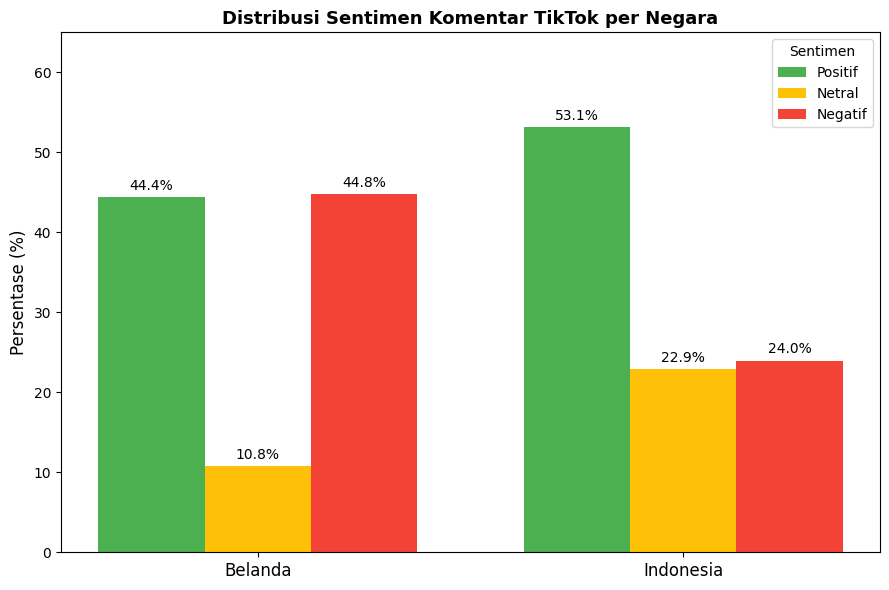

✅ Grafik tersimpan: grafik_sentimen_negara.png


In [ ]:
# ===== GRAFIK DISTRIBUSI SENTIMEN PER NEGARA =====
import matplotlib.pyplot as plt
import numpy as np

# Hitung persentase per negara
tabel = df.groupby('negara')['label'].value_counts(normalize=True).unstack(fill_value=0) * 100
tabel = tabel[['positif', 'netral', 'negatif']]  # urutan kolom

# Setup grafik batang berkelompok
negara = tabel.index.tolist()
x = np.arange(len(negara))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 6))
warna = {'positif': '#4CAF50', 'netral': '#FFC107', 'negatif': '#F44336'}

bar1 = ax.bar(x - width, tabel['positif'], width, label='Positif', color=warna['positif'])
bar2 = ax.bar(x, tabel['netral'], width, label='Netral', color=warna['netral'])
bar3 = ax.bar(x + width, tabel['negatif'], width, label='Negatif', color=warna['negatif'])

# Tambah label angka di atas tiap batang
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        tinggi = bar.get_height()
        ax.annotate(f'{tinggi:.1f}%',
                    xy=(bar.get_x() + bar.get_width()/2, tinggi),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Persentase (%)', fontsize=12)
ax.set_title('Distribusi Sentimen Komentar TikTok per Negara', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(negara, fontsize=12)
ax.legend(title='Sentimen')
ax.set_ylim(0, 65)
plt.tight_layout()

# Simpan grafik ke Drive
plt.savefig('/content/drive/MyDrive/Dataset Nofita Skripsi/grafik_sentimen_negara.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Grafik tersimpan: grafik_sentimen_negara.png")

## 6. Split Data & TF-IDF

In [ ]:
# ===== SPLIT DATA (train/test) =====
from sklearn.model_selection import train_test_split

# X = teks final (hasil preprocessing), y = label sentimen
X = df['final_text']
y = df['label']

# Split 80% latih, 20% uji. stratify=y menjaga proporsi label seimbang di kedua set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))
print("\nDistribusi label data latih:")
print(y_train.value_counts())
print("\nDistribusi label data uji:")
print(y_test.value_counts())

Jumlah data latih: 1856
Jumlah data uji: 465

Distribusi label data latih:
label
positif    889
negatif    677
netral     290
Name: count, dtype: int64

Distribusi label data uji:
label
positif    222
negatif    170
netral      73
Name: count, dtype: int64


In [ ]:
# ===== TF-IDF (fit di data latih saja, transform ke uji) =====
from sklearn.feature_extraction.text import TfidfVectorizer

# Buat TF-IDF vectorizer
tfidf = TfidfVectorizer()

# PENTING: fit HANYA di data latih (mencegah data leakage)
X_train_tfidf = tfidf.fit_transform(X_train)

# Data uji hanya di-transform (pakai kosakata dari data latih)
X_test_tfidf = tfidf.transform(X_test)

print("Bentuk matriks TF-IDF data latih:", X_train_tfidf.shape)
print("Bentuk matriks TF-IDF data uji:", X_test_tfidf.shape)
print("\nJumlah fitur (kata unik):", len(tfidf.get_feature_names_out()))
print("\nContoh 20 fitur (kata):")
print(tfidf.get_feature_names_out()[:20])

Bentuk matriks TF-IDF data latih: (1856, 2368)
Bentuk matriks TF-IDF data uji: (465, 2368)

Jumlah fitur (kata unik): 2368

Contoh 20 fitur (kata):
['aaaoooo' 'abad' 'abadi' 'abang' 'abdi' 'abiis' 'abu' 'acara' 'aceh'
 'ada' 'adab' 'adamakan' 'adegan' 'adil' 'admin' 'administratif' 'aduh'
 'aesthetic' 'afrika' 'after']


In [ ]:
import pandas as pd

# Ambil contoh matriks TF-IDF (beberapa komentar + beberapa kata)
# Pakai X_train_tfidf & tfidf yang sudah dibuat

# Ambil 5 komentar pertama + beberapa kata yang muncul
contoh = pd.DataFrame(
    X_train_tfidf[:5].toarray(),
    columns=tfidf.get_feature_names_out()
)

# Pilih beberapa kata yang bobotnya tidak nol (biar kelihatan)
# Ambil kata-kata yang muncul di 5 komentar ini
kata_muncul = contoh.columns[(contoh != 0).any()][:8]
print("Contoh matriks TF-IDF (5 komentar x 8 kata):")
print(contoh[kata_muncul].round(3).to_string())

Contoh matriks TF-IDF (5 komentar x 8 kata):
   angkut    apa  apartemen   atas  bagaimana  bahaya   baik  begini
0    0.00  0.000      0.000  0.000      0.000    0.00  0.202   0.000
1    0.18  0.105      0.186  0.144      0.249    0.00  0.000   0.000
2    0.00  0.000      0.000  0.000      0.000    0.00  0.000   0.317
3    0.00  0.000      0.000  0.000      0.000    0.00  0.000   0.000
4    0.00  0.000      0.000  0.000      0.000    0.46  0.000   0.337


In [ ]:
import pandas as pd
# Cari komentar yang mengandung kata bermakna
kata_pilih = ['sampah','daur','plastik','botol']
matriks = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Ambil 5 komentar yang punya bobot untuk kata-kata ini
mask = (matriks[kata_pilih] > 0).any(axis=1)
contoh = matriks[mask][kata_pilih].head(5)
print(contoh.round(3).to_string())

    sampah   daur  plastik  botol
0    0.125  0.000      0.0    0.0
1    0.231  0.122      0.0    0.0
6    0.000  0.000      0.0    0.2
9    0.320  0.000      0.0    0.0
13   0.542  0.000      0.0    0.0


In [ ]:
# ===== RANDOM OVERSAMPLING (hanya di data latih) =====
from imblearn.over_sampling import RandomOverSampler

print("Distribusi label SEBELUM oversampling (data latih):")
print(y_train.value_counts())

# Terapkan Random Oversampling HANYA pada data latih
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_tfidf, y_train)

print("\nDistribusi label SESUDAH oversampling (data latih):")
print(y_train_resampled.value_counts())

print("\nJumlah data latih sebelum:", X_train_tfidf.shape[0])
print("Jumlah data latih sesudah:", X_train_resampled.shape[0])
print("\nData uji TIDAK di-oversampling (tetap asli):", X_test_tfidf.shape[0])

Distribusi label SEBELUM oversampling (data latih):
label
positif    889
negatif    677
netral     290
Name: count, dtype: int64

Distribusi label SESUDAH oversampling (data latih):
label
negatif    889
positif    889
netral     889
Name: count, dtype: int64

Jumlah data latih sebelum: 1856
Jumlah data latih sesudah: 2667

Data uji TIDAK di-oversampling (tetap asli): 465


## 7. Klasifikasi Model

### 7.1 Naive Bayes

In [ ]:
# ===== 7.1 NAIVE BAYES =====
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Buat & latih model Naive Bayes (pakai data latih yang sudah di-oversampling)
nb = MultinomialNB()
nb.fit(X_train_resampled, y_train_resampled)

# Prediksi ke data uji
y_pred_nb = nb.predict(X_test_tfidf)

# Evaluasi
akurasi_nb = accuracy_score(y_test, y_pred_nb)
print("=== NAIVE BAYES ===")
print("Akurasi:", round(akurasi_nb * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

=== NAIVE BAYES ===
Akurasi: 71.83 %

Classification Report:
              precision    recall  f1-score   support

     negatif       0.64      0.82      0.72       170
      netral       0.65      0.42      0.51        73
     positif       0.82      0.74      0.78       222

    accuracy                           0.72       465
   macro avg       0.70      0.66      0.67       465
weighted avg       0.73      0.72      0.71       465


Confusion Matrix:
[[139   8  23]
 [ 29  31  13]
 [ 49   9 164]]


### 7.2 Support Vector Machine

In [ ]:
# ===== 7.2 SUPPORT VECTOR MACHINE (SVM) =====
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_resampled, y_train_resampled)

y_pred_svm = svm.predict(X_test_tfidf)

akurasi_svm = accuracy_score(y_test, y_pred_svm)
print("=== SUPPORT VECTOR MACHINE (SVM) ===")
print("Akurasi:", round(akurasi_svm * 100, 2), "%")
print("")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm))
print("")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

=== SUPPORT VECTOR MACHINE (SVM) ===
Akurasi: 74.62 %

Classification Report:
              precision    recall  f1-score   support

     negatif       0.81      0.76      0.78       170
      netral       0.53      0.42      0.47        73
     positif       0.76      0.84      0.80       222

    accuracy                           0.75       465
   macro avg       0.70      0.68      0.68       465
weighted avg       0.74      0.75      0.74       465


Confusion Matrix:
[[129  11  30]
 [ 12  31  30]
 [ 18  17 187]]


In [ ]:
# ===== SIMPAN HASIL AKURASI MODEL =====
import pandas as pd

# Simpan ringkasan akurasi model yang sudah selesai
hasil_model = pd.DataFrame({
    'Model': ['Naive Bayes', 'SVM'],
    'Akurasi (%)': [round(akurasi_nb*100, 2), round(akurasi_svm*100, 2)]
})

hasil_model.to_excel('/content/drive/MyDrive/Dataset Nofita Skripsi/hasil_akurasi_model.xlsx', index=False)
print("✅ Hasil akurasi tersimpan!")
print(hasil_model)

### 7.3 Logistic Regression

In [ ]:
# ===== 7.3 LOGISTIC REGRESSION =====
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr.predict(X_test_tfidf)

akurasi_lr = accuracy_score(y_test, y_pred_lr)
print("=== LOGISTIC REGRESSION ===")
print("Akurasi:", round(akurasi_lr * 100, 2), "%")
print("")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

=== LOGISTIC REGRESSION ===
Akurasi: 75.91 %

Classification Report:
              precision    recall  f1-score   support

     negatif       0.79      0.74      0.77       170
      netral       0.60      0.60      0.60        73
     positif       0.79      0.82      0.80       222

    accuracy                           0.76       465
   macro avg       0.73      0.72      0.72       465
weighted avg       0.76      0.76      0.76       465


Confusion Matrix:
[[126  14  30]
 [  9  44  20]
 [ 24  15 183]]


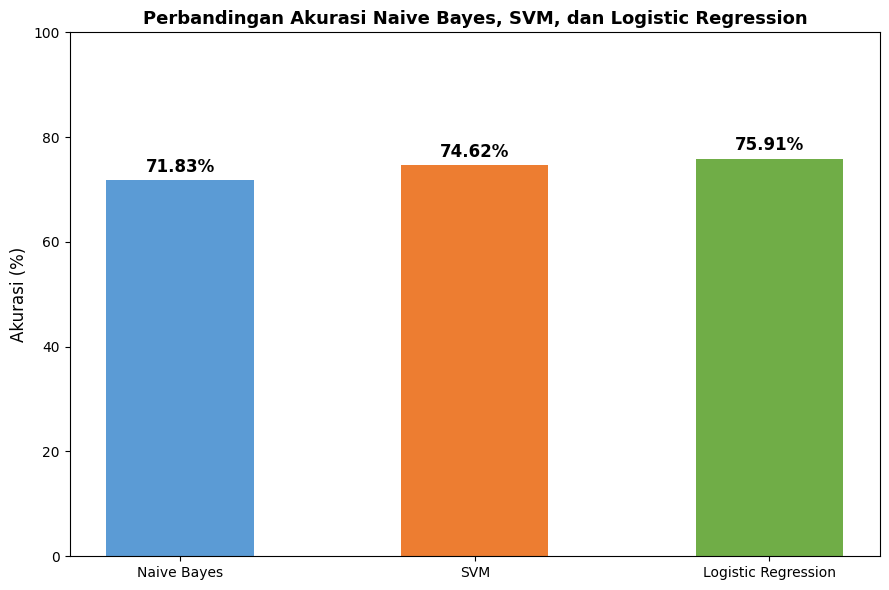

✅ Grafik tersimpan: grafik_perbandingan_model.png


In [ ]:
# ===== GRAFIK PERBANDINGAN AKURASI 3 MODEL =====
import matplotlib.pyplot as plt

model = ['Naive Bayes', 'SVM', 'Logistic Regression']
akurasi = [akurasi_nb*100, akurasi_svm*100, akurasi_lr*100]
warna = ['#5B9BD5', '#ED7D31', '#70AD47']

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(model, akurasi, color=warna, width=0.5)

# Label angka di atas tiap batang
for bar in bars:
    tinggi = bar.get_height()
    ax.annotate(f'{tinggi:.2f}%',
                xy=(bar.get_x() + bar.get_width()/2, tinggi),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Akurasi (%)', fontsize=12)
ax.set_title('Perbandingan Akurasi Naive Bayes, SVM, dan Logistic Regression',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
plt.tight_layout()

# Simpan ke Drive
plt.savefig('/content/drive/MyDrive/Dataset Nofita Skripsi/grafik_perbandingan_model.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Grafik tersimpan: grafik_perbandingan_model.png")

## 8. Evaluasi Model

In [ ]:
# ===== 8. EVALUASI MODEL: rangkum metrik 3 model =====
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Kumpulkan metrik tiap model (pakai weighted average)
def hitung_metrik(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred)*100,
        'Precision': precision_score(y_true, y_pred, average='weighted')*100,
        'Recall': recall_score(y_true, y_pred, average='weighted')*100,
        'F1-Score': f1_score(y_true, y_pred, average='weighted')*100
    }

hasil = {
    'Naive Bayes': hitung_metrik(y_test, y_pred_nb),
    'SVM': hitung_metrik(y_test, y_pred_svm),
    'Logistic Regression': hitung_metrik(y_test, y_pred_lr)
}

# Buat tabel perbandingan
tabel_evaluasi = pd.DataFrame(hasil).T.round(2)
print("=== TABEL EVALUASI 3 MODEL ===")
print(tabel_evaluasi)

# Simpan ke Drive
tabel_evaluasi.to_excel('/content/drive/MyDrive/Dataset Nofita Skripsi/tabel_evaluasi_model.xlsx')
print("\n✅ Tabel evaluasi tersimpan!")

=== TABEL EVALUASI 3 MODEL ===
                     Accuracy  Precision  Recall  F1-Score
Naive Bayes             71.83      72.71   71.83     71.41
SVM                     74.62      74.05   74.62     74.11
Logistic Regression     75.91      75.93   75.91     75.87

✅ Tabel evaluasi tersimpan!


## Confusion Matrix Visual

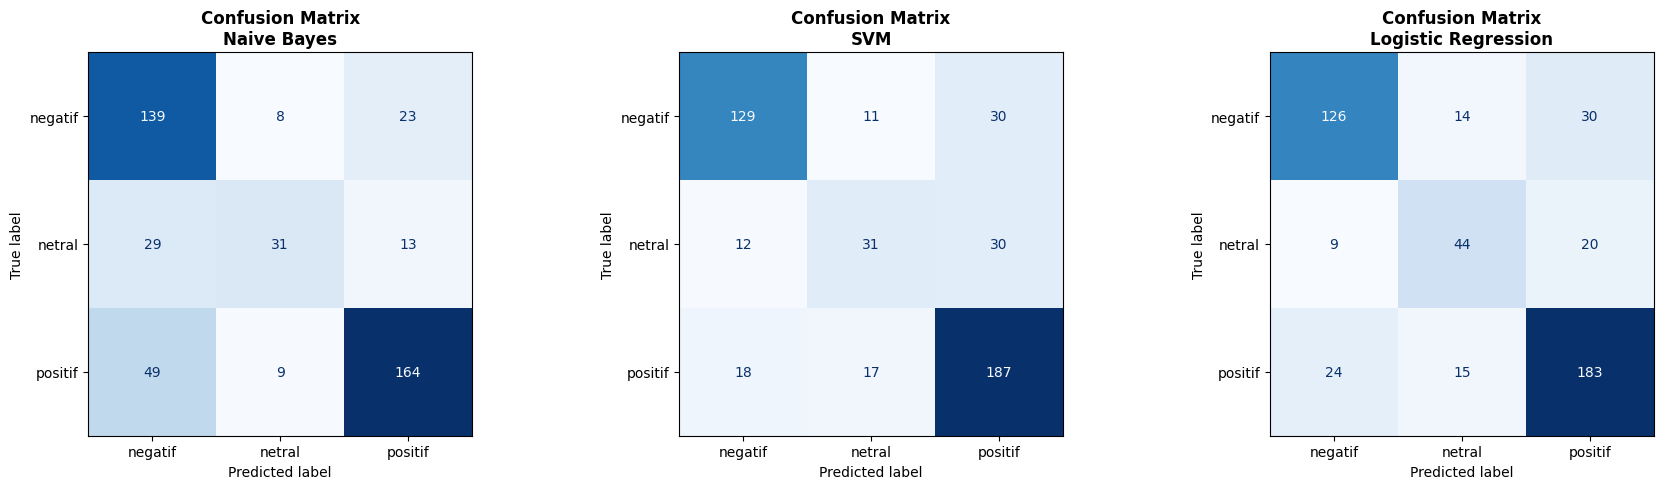

✅ Confusion matrix tersimpan!


In [ ]:
# ===== CONFUSION MATRIX VISUAL 3 MODEL =====
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

label_urut = ['negatif', 'netral', 'positif']
prediksi = {
    'Naive Bayes': y_pred_nb,
    'SVM': y_pred_svm,
    'Logistic Regression': y_pred_lr
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nama, y_pred) in zip(axes, prediksi.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, labels=label_urut,
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(f'Confusion Matrix\n{nama}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dataset Nofita Skripsi/confusion_matrix_3model.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix tersimpan!")

## 9. Perbandingan Performa Model

In [ ]:
# ===== 9. PERBANDINGAN MODEL: kesimpulan =====
print("=" * 55)
print("RINGKASAN PERBANDINGAN 3 MODEL")
print("=" * 55)
print(tabel_evaluasi)
print("")

# Cari model terbaik berdasarkan akurasi
model_terbaik = tabel_evaluasi['Accuracy'].idxmax()
akurasi_terbaik = tabel_evaluasi['Accuracy'].max()

print(f"Model dengan akurasi tertinggi: {model_terbaik} ({akurasi_terbaik:.2f}%)")
print("")
print("Urutan performa (dari tertinggi):")
urutan = tabel_evaluasi.sort_values('Accuracy', ascending=False)
for i, (nama, row) in enumerate(urutan.iterrows(), 1):
    print(f"{i}. {nama}: {row['Accuracy']:.2f}%")

RINGKASAN PERBANDINGAN 3 MODEL
                     Accuracy  Precision  Recall  F1-Score
Naive Bayes             71.83      72.71   71.83     71.41
SVM                     74.62      74.05   74.62     74.11
Logistic Regression     75.91      75.93   75.91     75.87

Model dengan akurasi tertinggi: Logistic Regression (75.91%)

Urutan performa (dari tertinggi):
1. Logistic Regression: 75.91%
2. SVM: 74.62%
3. Naive Bayes: 71.83%


In [ ]:
import pandas as pd
import ast
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel('/content/drive/MyDrive/Dataset Nofita Skripsi/data_labeling.xlsx')
for c in ['tokens','stem']:
    if c in df.columns:
        df[c] = df[c].apply(ast.literal_eval)
print("Data loaded:", len(df))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded: 2321
